# Ejercicio 9
## Remuestreo Bootstrap

In [1]:
#importamos las librerias necesarias
import numpy as np
import matplotlib.pyplot as plt

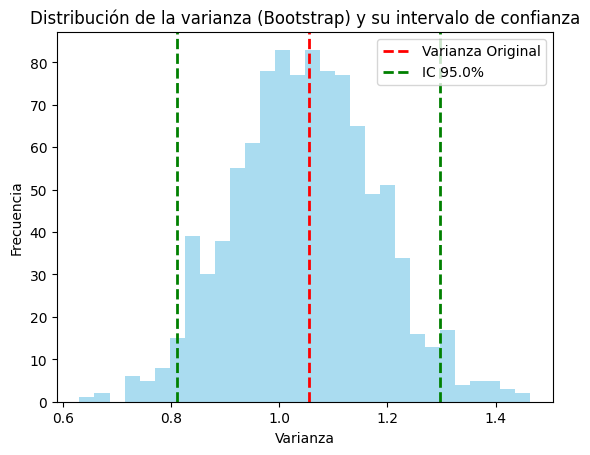

Varianza Original: 1.0541
Intervalo de Confianza del 95%: [0.8112, 1.2970]
Varianza de la distribución bootstrap: 0.0173
Error estándar de la estimación: 0.1316


In [ ]:
#Vamos a definir las funciones necesarias para realizar el remuestreo bootstrap y calcular el intervalo de confianza para la media de una muestra dada.

#Definimos la funcion para calcular varianza muestral

def calculo_varianza(muestra):
    return np.var(muestra, ddof=1) #varianza muestral


#Definimos la funcion para realizar el remuestreo bootstrap y calcular el intervalo de confianza para la varianza

def bootstrap_varianza(muestra, N=1000, alpha=0.05):

    # definimos una lista para almacenar las varianzas calculadas en cada remuestreo
    varianzas_bootstrap = []

    # Realizar N remuestreos
    for _ in range(N):
        # Creamos una muestra con reemplazo de los datos
        muestra_bootstrap = np.random.choice(muestra, size=len(muestra), replace=True)
        # Calculamos la varianza de la muestra
        varianza_muestra = calculo_varianza(muestra_bootstrap)
        varianzas_bootstrap.append(varianza_muestra)

    # Calcular percentiles para el intervalo de confianza
    limite_inferior = np.percentile(varianzas_bootstrap, (alpha / 2) * 100)
    limite_superior = np.percentile(varianzas_bootstrap, (1 - alpha / 2) * 100)

    return limite_inferior, limite_superior



# Generamos los datos de la muestra original
np.random.seed(37)
muestra = np.random.normal(loc=0, scale=1, size=100)

# Calculamos la varianza de la muestra original
varianza_original = calculo_varianza(muestra)

# Calculamos los intervalos de confianza con muestras Bootstrap
lim_inf, lim_sup = bootstrap_varianza(muestra, N=1000, alpha=0.05)

# Graficar el histograma de las varianzas obtenidas con Bootstrap
varianzas_bootstrap = [calculo_varianza(np.random.choice(muestra, size=len(muestra), replace=True)) for _ in range(1000)]

plt.hist(varianzas_bootstrap, bins=30, alpha=0.7, color='skyblue')
plt.axvline(varianza_original, color='red', linestyle='dashed', linewidth=2, label='Varianza Original')
plt.axvline(lim_inf, color='green', linestyle='dashed', linewidth=2, label=f'IC {100 * (1 - 0.05):.1f}% ')
plt.axvline(lim_sup, color='green', linestyle='dashed', linewidth=2)
plt.xlabel('Varianza')
plt.ylabel('Frecuencia')
plt.legend()
plt.title('Distribución de la varianza (Bootstrap) y su intervalo de confianza')
plt.show()  



# Calcular la varianza de la distribución bootstrap
varianza_bootstrap_dist = np.var(varianzas_bootstrap, ddof=1)
error_estandar_bootstrap = np.std(varianzas_bootstrap, ddof=1)

print(f'Varianza Original: {varianza_original:.4f}')
print(f'Intervalo de Confianza del 95%: [{lim_inf:.4f}, {lim_sup:.4f}]')
print(f'Varianza de la distribución bootstrap: {varianza_bootstrap_dist:.4f}')
print(f'Error estándar de la estimación: {error_estandar_bootstrap:.4f}')

## Nuevamente lo mismo, pero generamos muestra con fisher-tippet

Varianza estimada: 1.599630185814886
Intervalo de confianza (95%): (np.float64(1.4431847747713895), np.float64(1.755979366190344))
Valor teórico: 1.6449340668482264
Desviación estándar de la distribución bootstrap: 0.08331813481592813


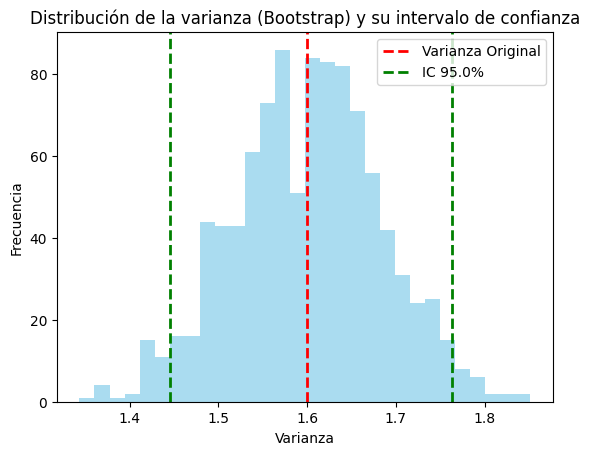

In [ ]:
#Vamos a definir las funciones necesarias para realizar el remuestreo bootstrap y calcular el intervalo de confianza para la media de una muestra dada.

#Definimos la funcion para calcular varianza muestral

def calculo_varianza(muestra):
    return np.var(muestra, ddof=1) #varianza muestral


#Definimos la funcion para calcular 

def bootstrap_varianza(muestra, N=1000, alpha=0.05):

    # definimos una lista para almacenar las varianzas calculadas en cada remuestreo
    varianzas_bootstrap = []

    # Realizar N remuestreos
    for _ in range(N):
        # Creamos una muestra con reemplazo de los datos
        muestra_bootstrap = np.random.choice(muestra, size=len(muestra), replace=True)
        # Calculamos la varianza de la muestra
        varianza_muestra = calculo_varianza(muestra_bootstrap)
        varianzas_bootstrap.append(varianza_muestra)

    # Calcular percentiles para el intervalo de confianza
    limite_inferior = np.percentile(varianzas_bootstrap, (alpha / 2) * 100)
    limite_superior = np.percentile(varianzas_bootstrap, (1 - alpha / 2) * 100)

    return limite_inferior, limite_superior



# Generamos los datos de la muestra original
np.random.seed(42)
muestra = np.random.gumbel(loc=0, scale=1, size=1000)


# Calculamos la varianza de la muestra original
varianza_original = calculo_varianza(muestra)

# Calculamos los intervalos de confianza con muestras Bootstrap
lim_inf, lim_sup = bootstrap_varianza(muestra, N=1000, alpha=0.05)

# Graficar el histograma de las varianzas obtenidas con Bootstrap
varianzas_bootstrap = [calculo_varianza(np.random.choice(muestra, size=len(muestra), replace=True)) for _ in range(1000)]

var_estimada = calculo_varianza(muestra)
li, ls = bootstrap_varianza(muestra)

# CALCULAR LA DESVIACIÓN ESTÁNDAR DE LA DISTRIBUCIÓN BOOTSTRAP
desviacion_estandar = np.std(varianzas_bootstrap, ddof=1) #ddof=1 para obtener la desviación estándar muestral

print("Varianza estimada:", var_estimada)
print("Intervalo de confianza (95%):", (li, ls))
print("Valor teórico:", np.pi**2 / 6)
print("Desviación estándar de la distribución bootstrap:", desviacion_estandar)


plt.hist(varianzas_bootstrap, bins=30, alpha=0.7, color='skyblue')
plt.axvline(varianza_original, color='red', linestyle='dashed', linewidth=2, label='Varianza Original')
plt.axvline(lim_inf, color='green', linestyle='dashed', linewidth=2, label=f'IC {100 * (1 - 0.05):.1f}% ')
plt.axvline(lim_sup, color='green', linestyle='dashed', linewidth=2)
plt.xlabel('Varianza')
plt.ylabel('Frecuencia')
plt.legend()
plt.title('Distribución de la varianza (Bootstrap) y su intervalo de confianza')
plt.show()

## Analicemos los efectos de los tamaños de las muestras

In [4]:
for n in [50, 100, 500, 1000, 10000]:
    datos = np.random.gumbel(loc=0, scale=1, size=n)
    var = calculo_varianza(datos)
    li, ls = bootstrap_varianza(datos)
    print(f"N={n} → Var: {var:.4f}, IC: ({li:.4f}, {ls:.4f})")


N=50 → Var: 2.4836, IC: (1.1467, 4.0408)
N=100 → Var: 1.9721, IC: (1.1670, 2.9056)
N=500 → Var: 1.7763, IC: (1.4721, 2.1326)
N=1000 → Var: 1.6070, IC: (1.3925, 1.8580)
N=10000 → Var: 1.6533, IC: (1.5853, 1.7158)
